In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

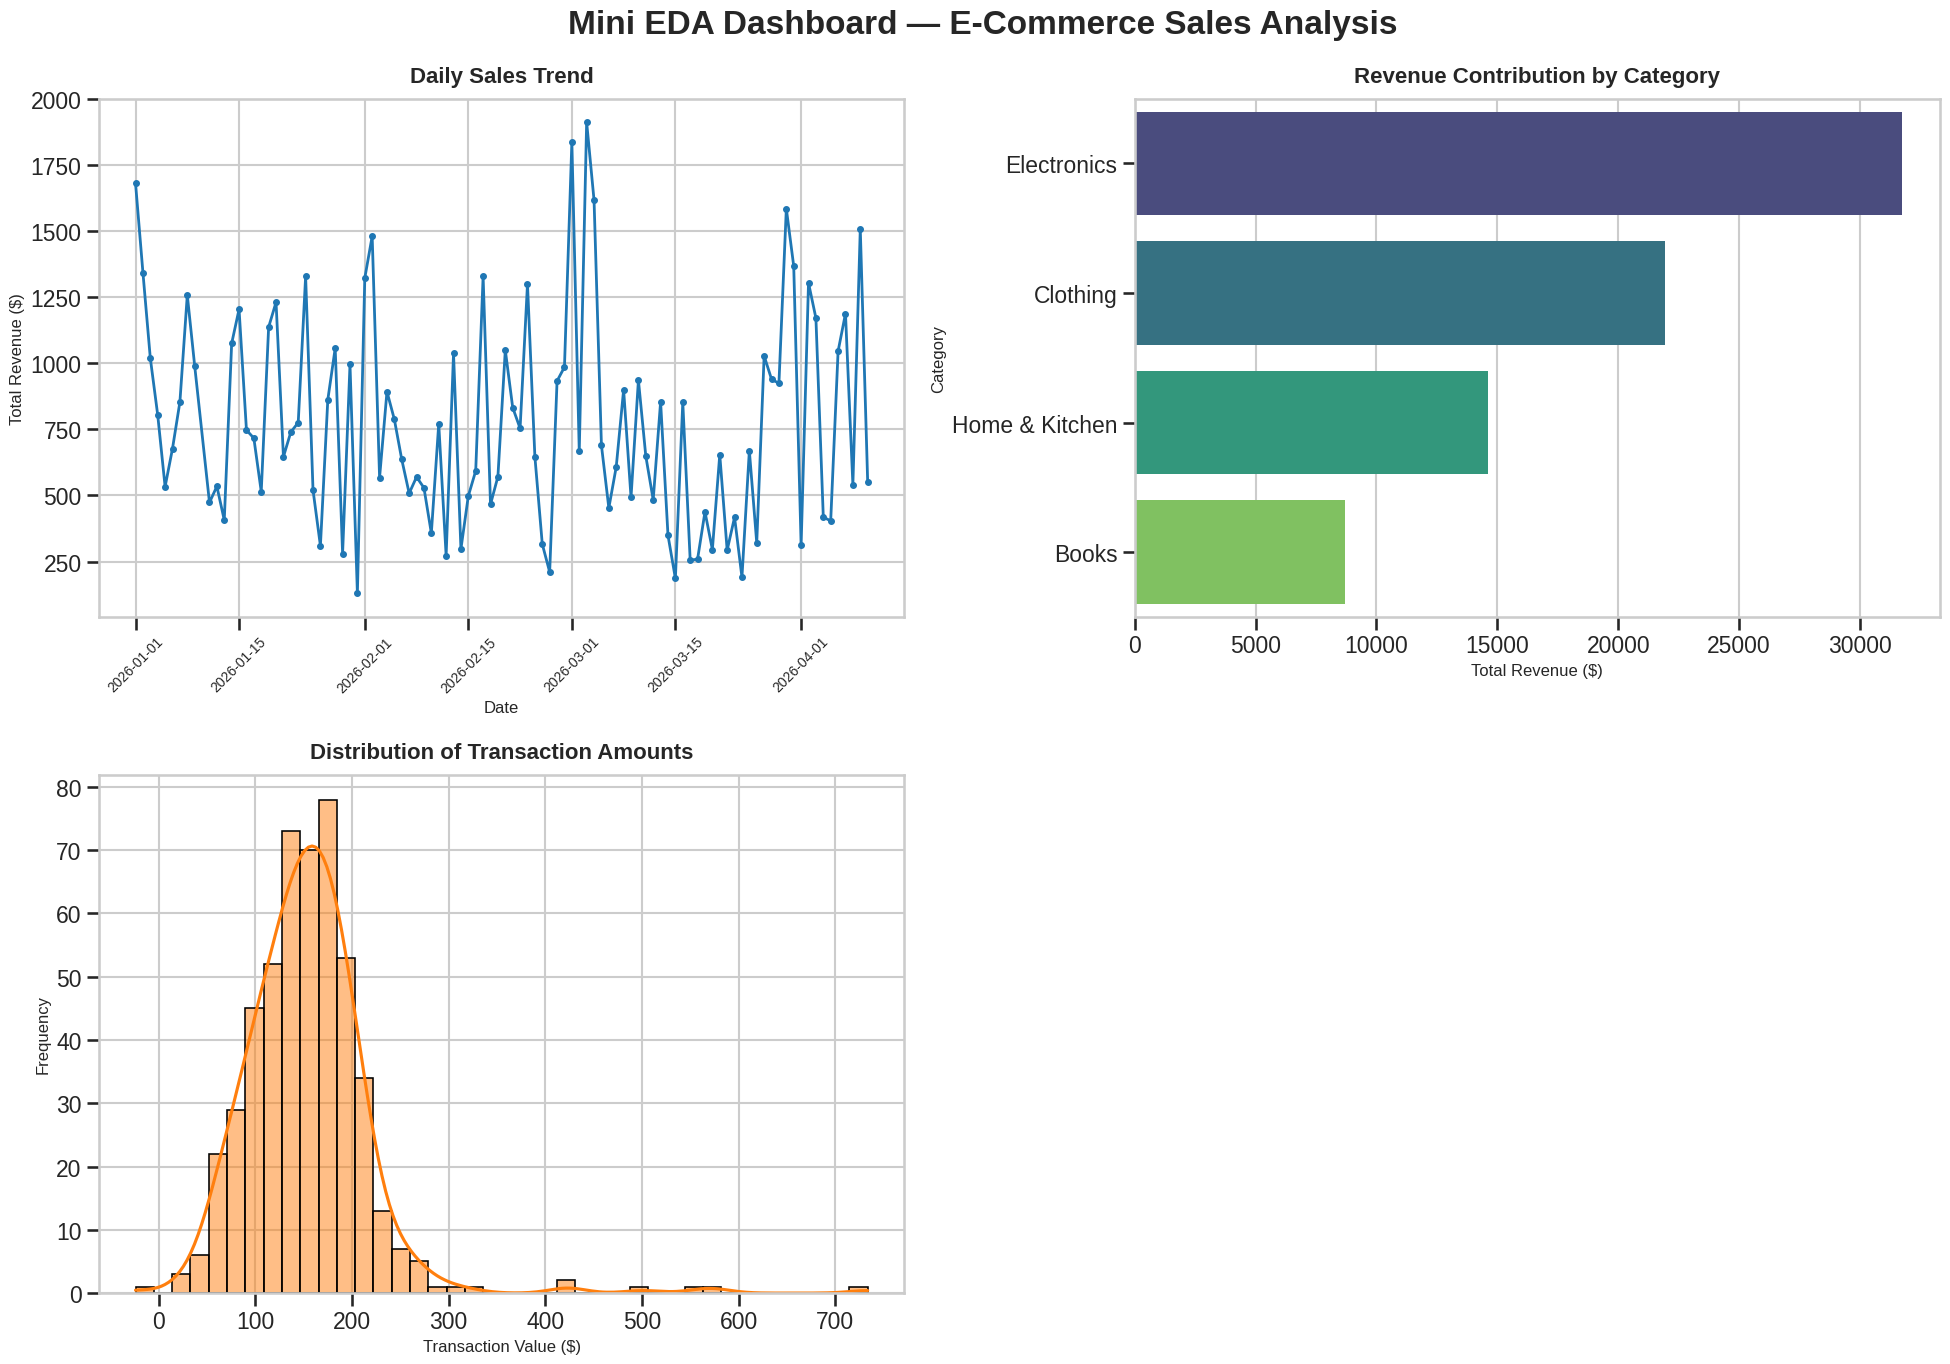

In [36]:
# 1. Generate a Mock Dataset (Telling an E-commerce Story)
np.random.seed(42)
dates = pd.date_range(start="2026-01-01", periods=100, freq="D")
categories = ["Electronics", "Clothing", "Home & Kitchen", "Books"]

data = {
    "Date": np.random.choice(dates, size = 500),
    "Category": np.random.choice(categories, size=500, p=[0.4, 0.3, 0.2, 0.1]),
    "Transaction_Amount": np.random.normal(loc=150, scale=50, size=500)
}

df = pd.DataFrame(data)

# Injecting some artificial outliers (extreme high-value transactions)
outlier_indices = np.random.choice(df.index, size=7)
df.loc[outlier_indices, 'Transaction_Amount'] = df.loc[outlier_indices, 'Transaction_Amount'] * 4

# Data Processing for Plots
trend_df = df.groupby('Date')['Transaction_Amount'].sum().reset_index()
cat_df = df.groupby('Category')['Transaction_Amount'].sum().reset_index().sort_values(by='Transaction_Amount', ascending=False)

# 2. Initialize the Dashboard Subplots (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("Mini EDA Dashboard — E-Commerce Sales Analysis", fontsize=24, fontweight='bold', y=0.98)

# --- Plot 1: Line Chart (Trend over Time) ---
axes[0, 0].plot(trend_df['Date'], trend_df['Transaction_Amount'], color='#1f77b4', linewidth=2, marker='o', markersize=4)
axes[0, 0].set_title("Daily Sales Trend", fontsize=16, fontweight='bold', pad=12)
axes[0, 0].set_xlabel("Date", fontsize=12)
axes[0, 0].set_ylabel("Total Revenue ($)", fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45, labelsize=10)

# --- Plot 2: Bar Chart (Category Comparison) ---
sns.barplot(x='Transaction_Amount', y='Category', data=cat_df, ax=axes[0, 1], palette='viridis',  hue ='Category')
axes[0, 1].set_title("Revenue Contribution by Category", fontsize=16, fontweight='bold', pad=12)
axes[0, 1].set_xlabel("Total Revenue ($)", fontsize=12)
axes[0, 1].set_ylabel("Category", fontsize=12)

# --- Plot 3: Histogram (Distribution of Transactions) ---
sns.histplot(df['Transaction_Amount'], bins=40, kde=True, ax=axes[1, 0], color='#ff7f0e')
axes[1, 0].set_title("Distribution of Transaction Amounts", fontsize=16, fontweight='bold', pad=12)
axes[1, 0].set_xlabel("Transaction Value ($)", fontsize=12)
axes[1, 0].set_ylabel("Frequency", fontsize=12)

# Adjust layout to prevent overlapping text
plt.tight_layout(rect=[0, 0, 1, 1])

#removing the last subplot (bottom right) for a cleaner look
fig.delaxes(axes[1, 1])

# Display Dashboard
plt.show()